#Нейронка на 2 вихря


## 1. Установка и импорт библиотек

In [ ]:
!pip install torch scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## 2. Загрузка данных

На этом этапе мы:

1. Загружаем CSV-файл с данными двух вихрей.
2. Читаем его в таблицу (DataFrame).
3. Убираем лишние пробелы в названиях колонок.
4. Проверяем первые строки таблицы, чтобы убедиться,
   что данные загрузились корректно.

В датасете содержатся:

- `distance` — расстояние между вихрями
- `intI`, `intJ` — параметры системы
- `GE` — энергия системы (целевая переменная)
- `dkappa` — параметр материала

Для обучения модели нам понадобятся:
- входы: `distance`, `intI`, `intJ`
- выход: `GE`

In [ ]:
file_path = "/content/sample_data/Два вихря.csv"

df = pd.read_csv(file_path)

# Убираем пробелы в названиях колонок
df.columns = df.columns.str.strip()

df.head()

,distance,intI,intJ,GE,dkappa
0,22.0820,7.34576,5.39146,3.29011,-0.3
1,21.7804,7.34576,5.39146,3.29011,-0.3
2,21.9460,7.34576,5.39146,3.29011,-0.3
3,19.5786,7.34576,5.39146,3.29011,-0.3
4,21.3288,7.34576,5.39146,3.29011,-0.3


## 3. Подготовка данных

На этом этапе мы:

1. Отделяем входные параметры (X) от целевой переменной (y).
2. Нормализуем данные (это важно для стабильного обучения нейросети).
3. Делим данные на обучающую и тестовую выборки.
4. Преобразуем данные в формат PyTorch (тензоры).


In [ ]:
# Входы и цель
X = df[['distance', 'intI', 'intJ']].values
y = df['GE'].values.reshape(-1, 1)

# Масштабирование
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# В тензоры
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

## 4. Создание нейросети

Мы создаём полносвязную нейронную сеть (MLP).

Архитектура:

- Входной слой: 3 параметра (distance, intI, intJ)
- Два скрытых слоя по 64 нейрона
- Функция активации ReLU
- Выходной слой: 1 нейрон (предсказание энергии GE)

Это стандартная архитектура для задачи регрессии.

Также мы задаём:
- функцию потерь MSE (среднеквадратичная ошибка),
- оптимизатор Adam.

In [ ]:
class VortexNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

model = VortexNet()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 5. Обучение модели

На этом этапе происходит обучение нейросети.

Процесс:

1. Модель делает предсказание.
2. Считается ошибка (MSE).
3. Вычисляются градиенты.
4. Обновляются веса модели.

Этот процесс повторяется много раз (эпохи),
пока ошибка не станет минимальной.

Мы выводим значение ошибки каждые несколько эпох,
чтобы контролировать процесс обучения.

In [ ]:
epochs = 200
train_losses = []

for epoch in range(epochs):
    model.train()

    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [20/200], Loss: 0.561020
Epoch [40/200], Loss: 0.349079
Epoch [60/200], Loss: 0.329162
Epoch [80/200], Loss: 0.319883
Epoch [100/200], Loss: 0.315222
Epoch [120/200], Loss: 0.311822
Epoch [140/200], Loss: 0.309457
Epoch [160/200], Loss: 0.307729
Epoch [180/200], Loss: 0.306228
Epoch [200/200], Loss: 0.304862


## 6. Оценка качества

Используем метрики:

- MSE — среднеквадратичная ошибка
- R² — коэффициент детерминации

Если R² близок к 1,
значит модель хорошо описывает зависимость.

Также строим график:
реальные значения vs предсказанные.

Если точки лежат вдоль диагонали —
модель работает хорошо.

In [ ]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)

# Возвращаем масштаб
test_pred = scaler_y.inverse_transform(test_pred.numpy())
y_test_real = scaler_y.inverse_transform(y_test.numpy())

mse = mean_squared_error(y_test_real, test_pred)
r2 = r2_score(y_test_real, test_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.986737072467804
R2: 0.6991127729415894


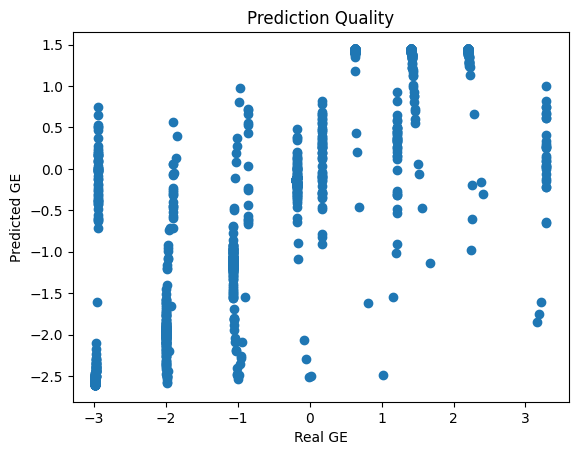

In [ ]:
plt.figure()
plt.scatter(y_test_real, test_pred)
plt.xlabel("Real GE")
plt.ylabel("Predicted GE")
plt.title("Prediction Quality")
plt.show()

## Вывод по обучению нейронной сети (2 вихря)

В ходе работы была обучена полносвязная нейронная сеть для предсказания энергии системы двух вихрей по параметрам:

- distance — расстояние между вихрями  
- intI, intJ — параметры системы  

Целевая переменная:  
- GE — энергия системы  

### Полученные метрики:

- MSE ≈ 0.99  
- R² ≈ 0.70  

### Анализ результата:

Коэффициент детерминации R² = 0.70 означает, что модель объясняет примерно 70% дисперсии энергии.  
Это говорит о том, что нейросеть частично уловила зависимость, однако точность предсказаний нельзя считать высокой.

По графику «реальные значения vs предсказанные» видно:

- заметный разброс точек относительно диагонали,
- ухудшение предсказаний для крайних значений энергии,
- неполное описание нелинейной зависимости.

### Возможные причины ограничения точности:

1. В модель не был включён параметр dkappa, который влияет на энергию.
2. Возможный перекос в распределении данных.
3. Сложная нелинейная физическая зависимость потенциала.

### Заключение:


Таким образом, нейросеть частично описывает двухвихревой потенциал, но требует доработки для получения физически точной модели.

#Нейронка на 3 вихря